In [3]:
# CELL 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.stats import ttest_ind

sns.set(style="whitegrid", font_scale=1.1)

In [4]:
# CELL 2 — Load Dataset

df = pd.read_csv("gene_expression_final.csv")
df.head()

,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMISGF3A/M97935_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMGAPDH/M33197_5_at,AFFX-HUMGAPDH/M33197_M_at,AFFX-HSAC07/X00351_5_at,AFFX-HSAC07/X00351_M_at,...,D64015_at,L78833_cds4_at,M93143_at,U29175_at,U58516_at,X06956_at,X83863_at,Z17240_at,M71243_f_at,target
0,-0.337145,0.317538,0.447209,1.362807,1.430069,1.376829,0.252946,-0.007002,0.426922,0.208093,...,0.247152,0.788599,0.500638,1.024736,-0.742225,0.396108,0.107630,0.212052,-0.447644,ALL
1,-0.337145,-0.592462,-0.438113,-0.367453,-0.994567,0.382240,0.334231,0.230495,0.426922,0.208093,...,-0.131519,-0.245322,-0.504430,-0.222795,0.454262,0.575569,0.083904,0.026572,-1.125984,ALL
2,-0.280501,1.489651,1.339442,0.847622,0.834333,0.890606,0.334231,0.427831,0.426922,0.208093,...,0.817583,1.390677,1.743779,0.029200,1.325750,-0.783546,0.721136,1.673316,-0.262024,ALL
3,-0.337145,-0.165024,-0.499724,0.762264,0.640126,0.685399,0.238732,0.026204,0.401259,0.208093,...,-1.080863,0.745768,0.058060,0.011272,0.448461,-0.734243,-0.291308,-0.910630,-0.883716,ALL
4,-0.337145,-0.518088,-0.279542,0.035237,0.735610,-0.522072,0.214057,0.352977,0.426922,0.208093,...,-1.644451,-0.873315,-1.019862,-0.218503,-0.162565,0.759997,-1.853055,0.132705,-1.125984,ALL


In [5]:
# CELL 3 — Dataset Info

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df["target"].value_counts())

Shape: (72, 3052)

Class Distribution:
target
ALL    47
AML    25
Name: count, dtype: int64


In [6]:
# CELL 4 — Encode Labels

le = LabelEncoder()
df["label"] = le.fit_transform(df["target"])   # ALL=0 / AML=1
df[["target","label"]].head()

,target,label
0,ALL,0
1,ALL,0
2,ALL,0
3,ALL,0
4,ALL,0


In [7]:
# CELL 5 — Split Features / Target

X = df.drop(["target", "label"], axis=1)
y = df["label"]

In [8]:
# CELL 6 — Standardize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# CELL 7 — PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = df["target"]

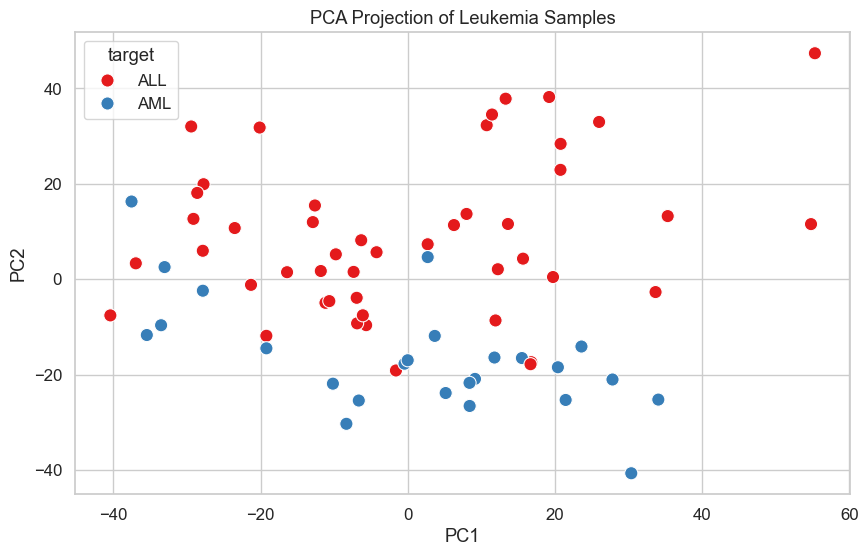

In [10]:
# CELL 8 — PCA Plot

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target",
    s=90,
    palette="Set1"
)
plt.title("PCA Projection of Leukemia Samples")
plt.show()

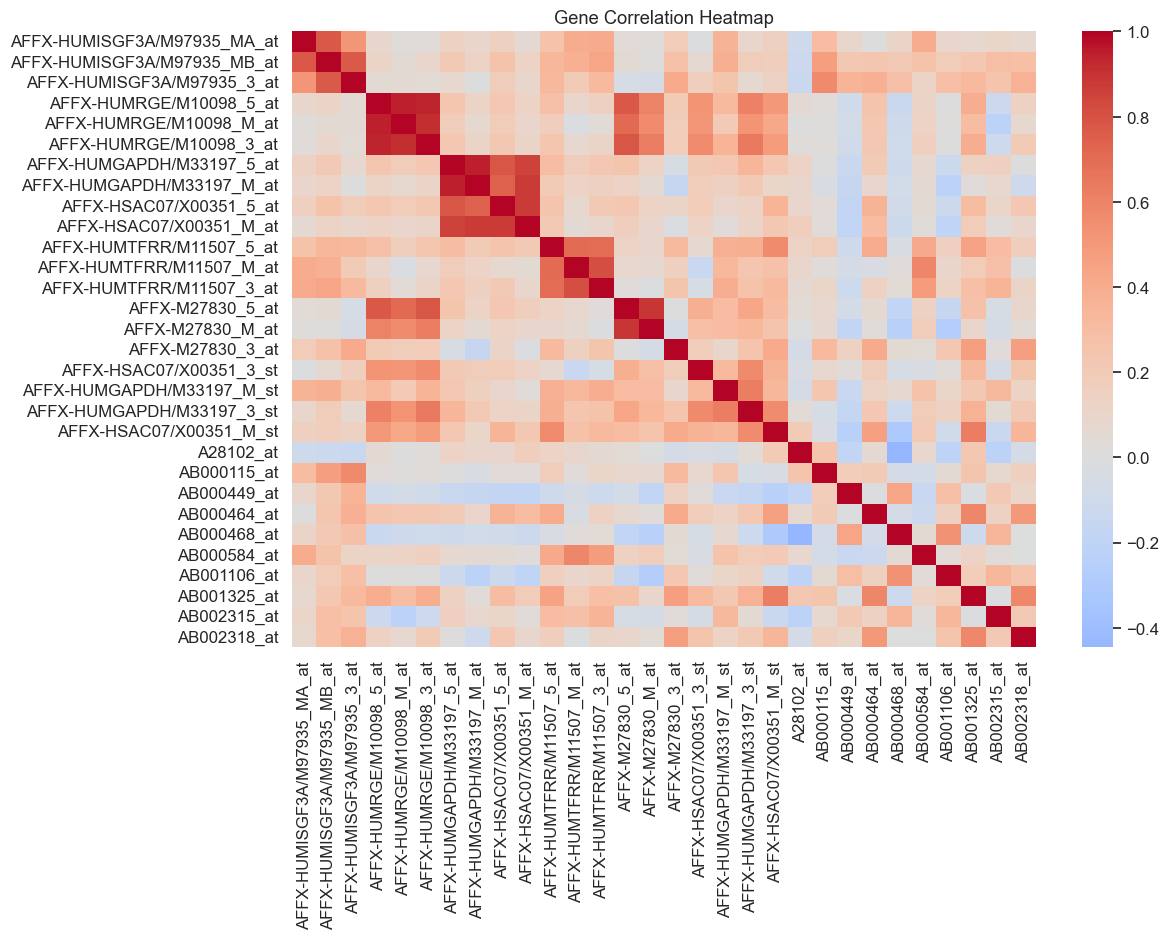

In [11]:
# CELL 9 — Heatmap of First 30 Genes

subset = X.iloc[:, :30]

plt.figure(figsize=(12,8))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Gene Correlation Heatmap")
plt.show()

In [12]:
# CELL 10 — T-test for all genes

all_samples = df[df["target"] == "ALL"]
aml_samples = df[df["target"] == "AML"]

results = []

for gene in X.columns:
    stat, p = ttest_ind(all_samples[gene], aml_samples[gene])
    
    mean_all = all_samples[gene].mean()
    mean_aml = aml_samples[gene].mean()
    
    log2fc = np.log2((mean_aml + 1e-6) / (mean_all + 1e-6))
    
    results.append([gene, p, log2fc])

deg = pd.DataFrame(results, columns=["Gene", "p_value", "log2FC"])
deg["neg_log10_p"] = -np.log10(deg["p_value"])
deg.head()

,Gene,p_value,log2FC,neg_log10_p
0,AFFX-HUMISGF3A/M97935_MA_at,0.093737,NaN,1.028091
1,AFFX-HUMISGF3A/M97935_MB_at,0.529790,-1.467859,0.275896
2,AFFX-HUMISGF3A/M97935_3_at,0.963079,-0.082609,0.016338
3,AFFX-HUMRGE/M10098_5_at,0.564578,0.450001,0.248276
4,AFFX-HUMRGE/M10098_M_at,0.204012,1.046189,0.690344


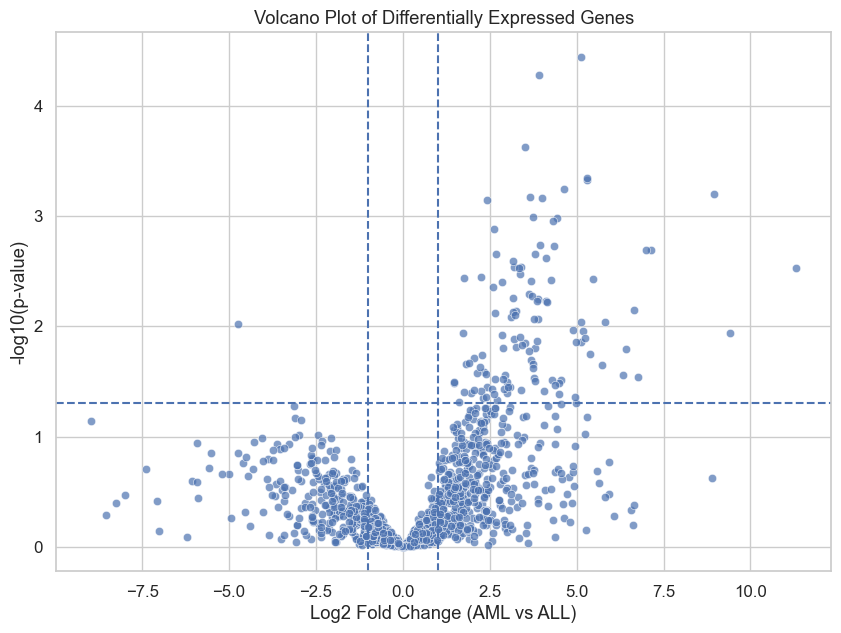

In [13]:
# CELL 11 — Volcano Plot

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=deg,
    x="log2FC",
    y="neg_log10_p",
    alpha=0.7
)

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")

plt.title("Volcano Plot of Differentially Expressed Genes")
plt.xlabel("Log2 Fold Change (AML vs ALL)")
plt.ylabel("-log10(p-value)")
plt.show()

In [14]:
# CELL 12 — Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# CELL 13 — Train Models

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel="linear", probability=True)
}

scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    scores[name] = acc

scores

{'Logistic Regression': 1.0, 'Random Forest': 1.0, 'SVM': 1.0}

In [16]:
# CELL 14 — Compare Models

score_df = pd.DataFrame(
    list(scores.items()),
    columns=["Model", "Accuracy"]
)

score_df.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,SVM,1.0


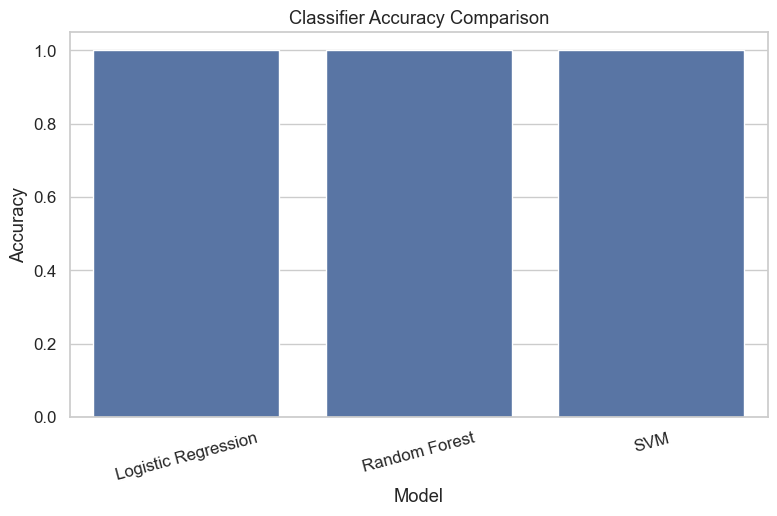

In [17]:
# CELL 15 — Accuracy Plot

plt.figure(figsize=(9,5))
sns.barplot(data=score_df, x="Model", y="Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

In [18]:
# CELL 16 — Best Model = Random Forest

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

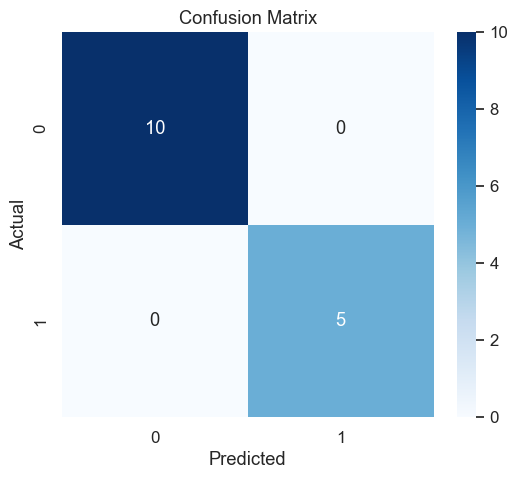

In [19]:
# CELL 17 — Confusion Matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

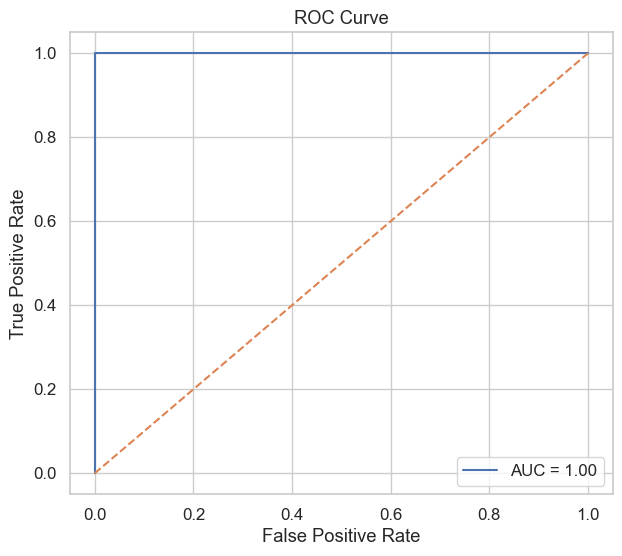

In [20]:
# CELL 18 — ROC Curve

probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

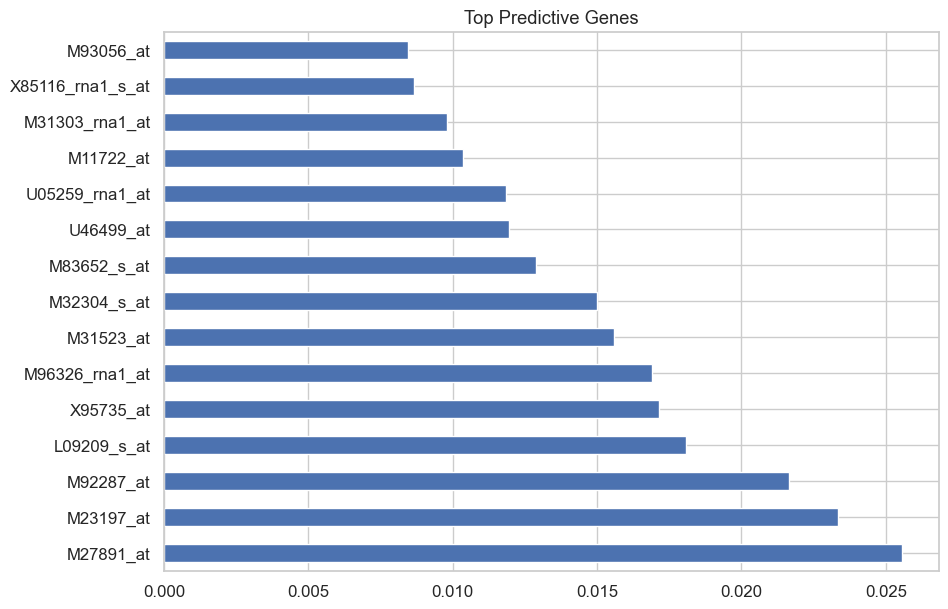

In [21]:
# CELL 19 — Top Biomarker Genes

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,7))
importance.plot(kind="barh")
plt.title("Top Predictive Genes")
plt.show()

In [22]:
# CELL 20 — Classification Report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

